In [1]:
from pathlib import Path
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
# import xclimate as xclim

In [2]:
OUTDIR = Path("/glade/derecho/scratch/bbuchovecky/derived/mlr")

mlr_time = xr.open_dataset(OUTDIR / "mlr_time_gridpoint_masked_1950-2014.nc")
mlr_ens = xr.open_dataset(OUTDIR / "mlr_ppe_gridpoint_masked_1950-2014.nc")
mlr_time_nors = xr.open_dataset(OUTDIR / "mlr_time_gridpoint_masked_noFSDS_1950-2014.nc")
mlr_ens_nors = xr.open_dataset(OUTDIR / "mlr_ppe_gridpoint_masked_noFSDS_1950-2014.nc")
mlr_time_tn_nors = xr.open_dataset(OUTDIR / "mlr_time_gridpoint_masked_tempnorm_noFSDS_1950-2014.nc")
mlr_ens_tn_nors = xr.open_dataset(OUTDIR / "mlr_ppe_gridpoint_masked_tempnorm_noFSDS_1950-2014.nc")

mlr_time_lai = xr.open_dataset(OUTDIR / "mlr_time_gridpoint_masked_onlyTLAI_1950-2014.nc")
mlr_ens_lai = xr.open_dataset(OUTDIR / "mlr_ppe_gridpoint_masked_onlyTLAI_1950-2014.nc")

vif_time = xr.open_dataset(OUTDIR / "vif_time_gridpoint_masked_1950-2014.nc")
vif_ens = xr.open_dataset(OUTDIR / "vif_ppe_gridpoint_masked_1950-2014.nc")
vif_time_nors = xr.open_dataset(OUTDIR / "vif_time_gridpoint_masked_noFSDS_1950-2014.nc")
vif_ens_nors = xr.open_dataset(OUTDIR / "vif_ppe_gridpoint_masked_noFSDS_1950-2014.nc")

COEFFS = [str(c).replace('_month_1', '') for c in mlr_time.coefficient.values]

DPI = 80

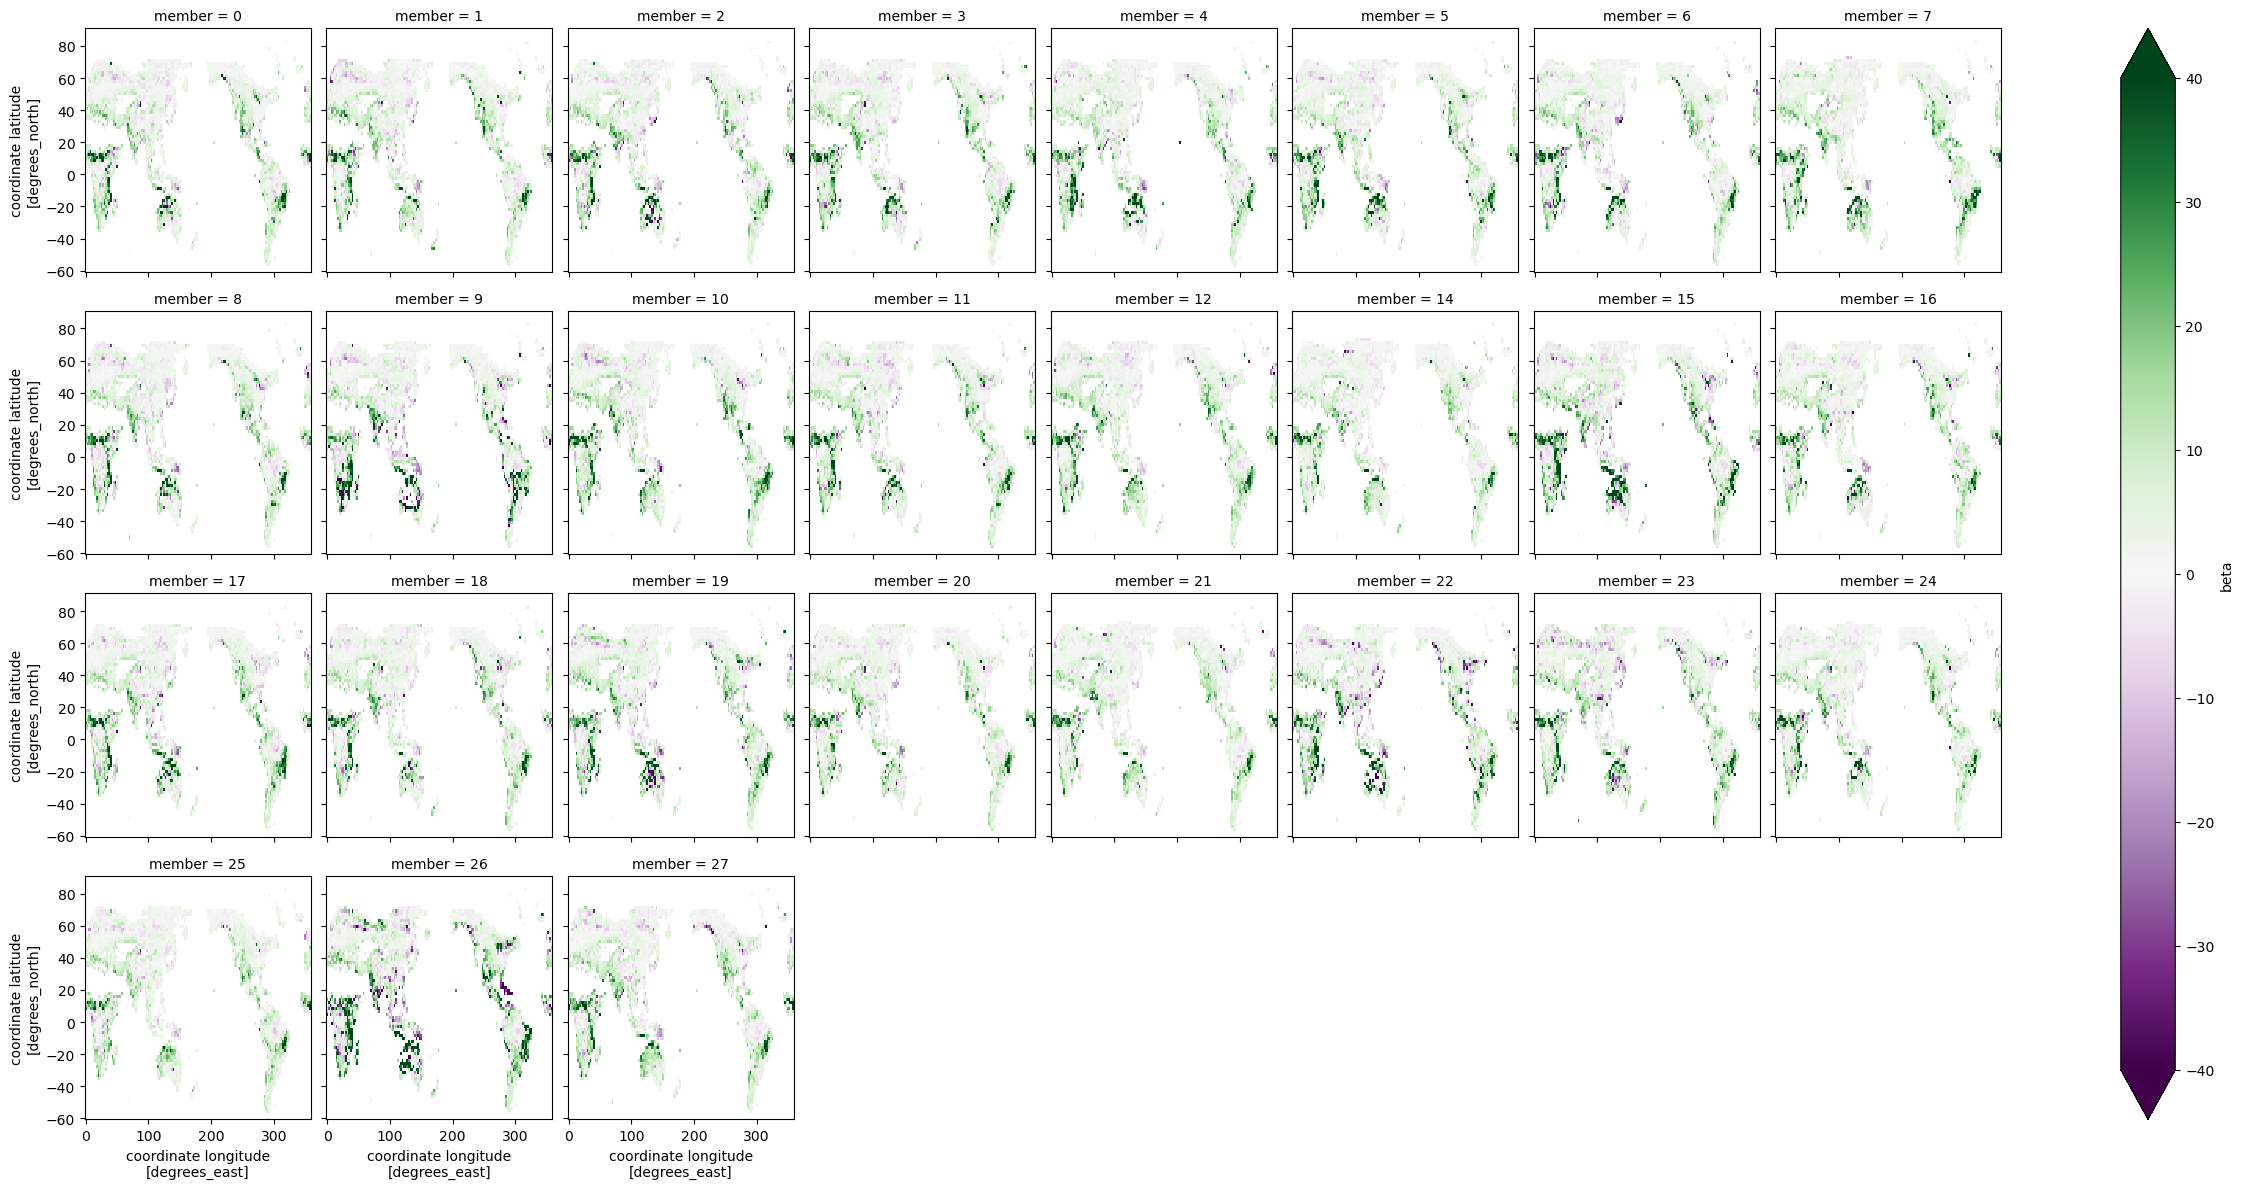

In [27]:
fg = mlr_time_lai.beta.sel(lat=slice(-60, None), coefficient="TLAI").plot(col='member', col_wrap=8, vmin=-40, vmax=40, cmap='PRGn')

for i in range(27):
    ax = fg.axs.ravel()[i]

    # r2 = mlr_time_lai.regression_metrics.isel(member=i).sel(metric='R2').mean(dim=['lat', 'lon']).values
    # ax.set_title(f"MEM={i}, R2={r2: 0.3f}")

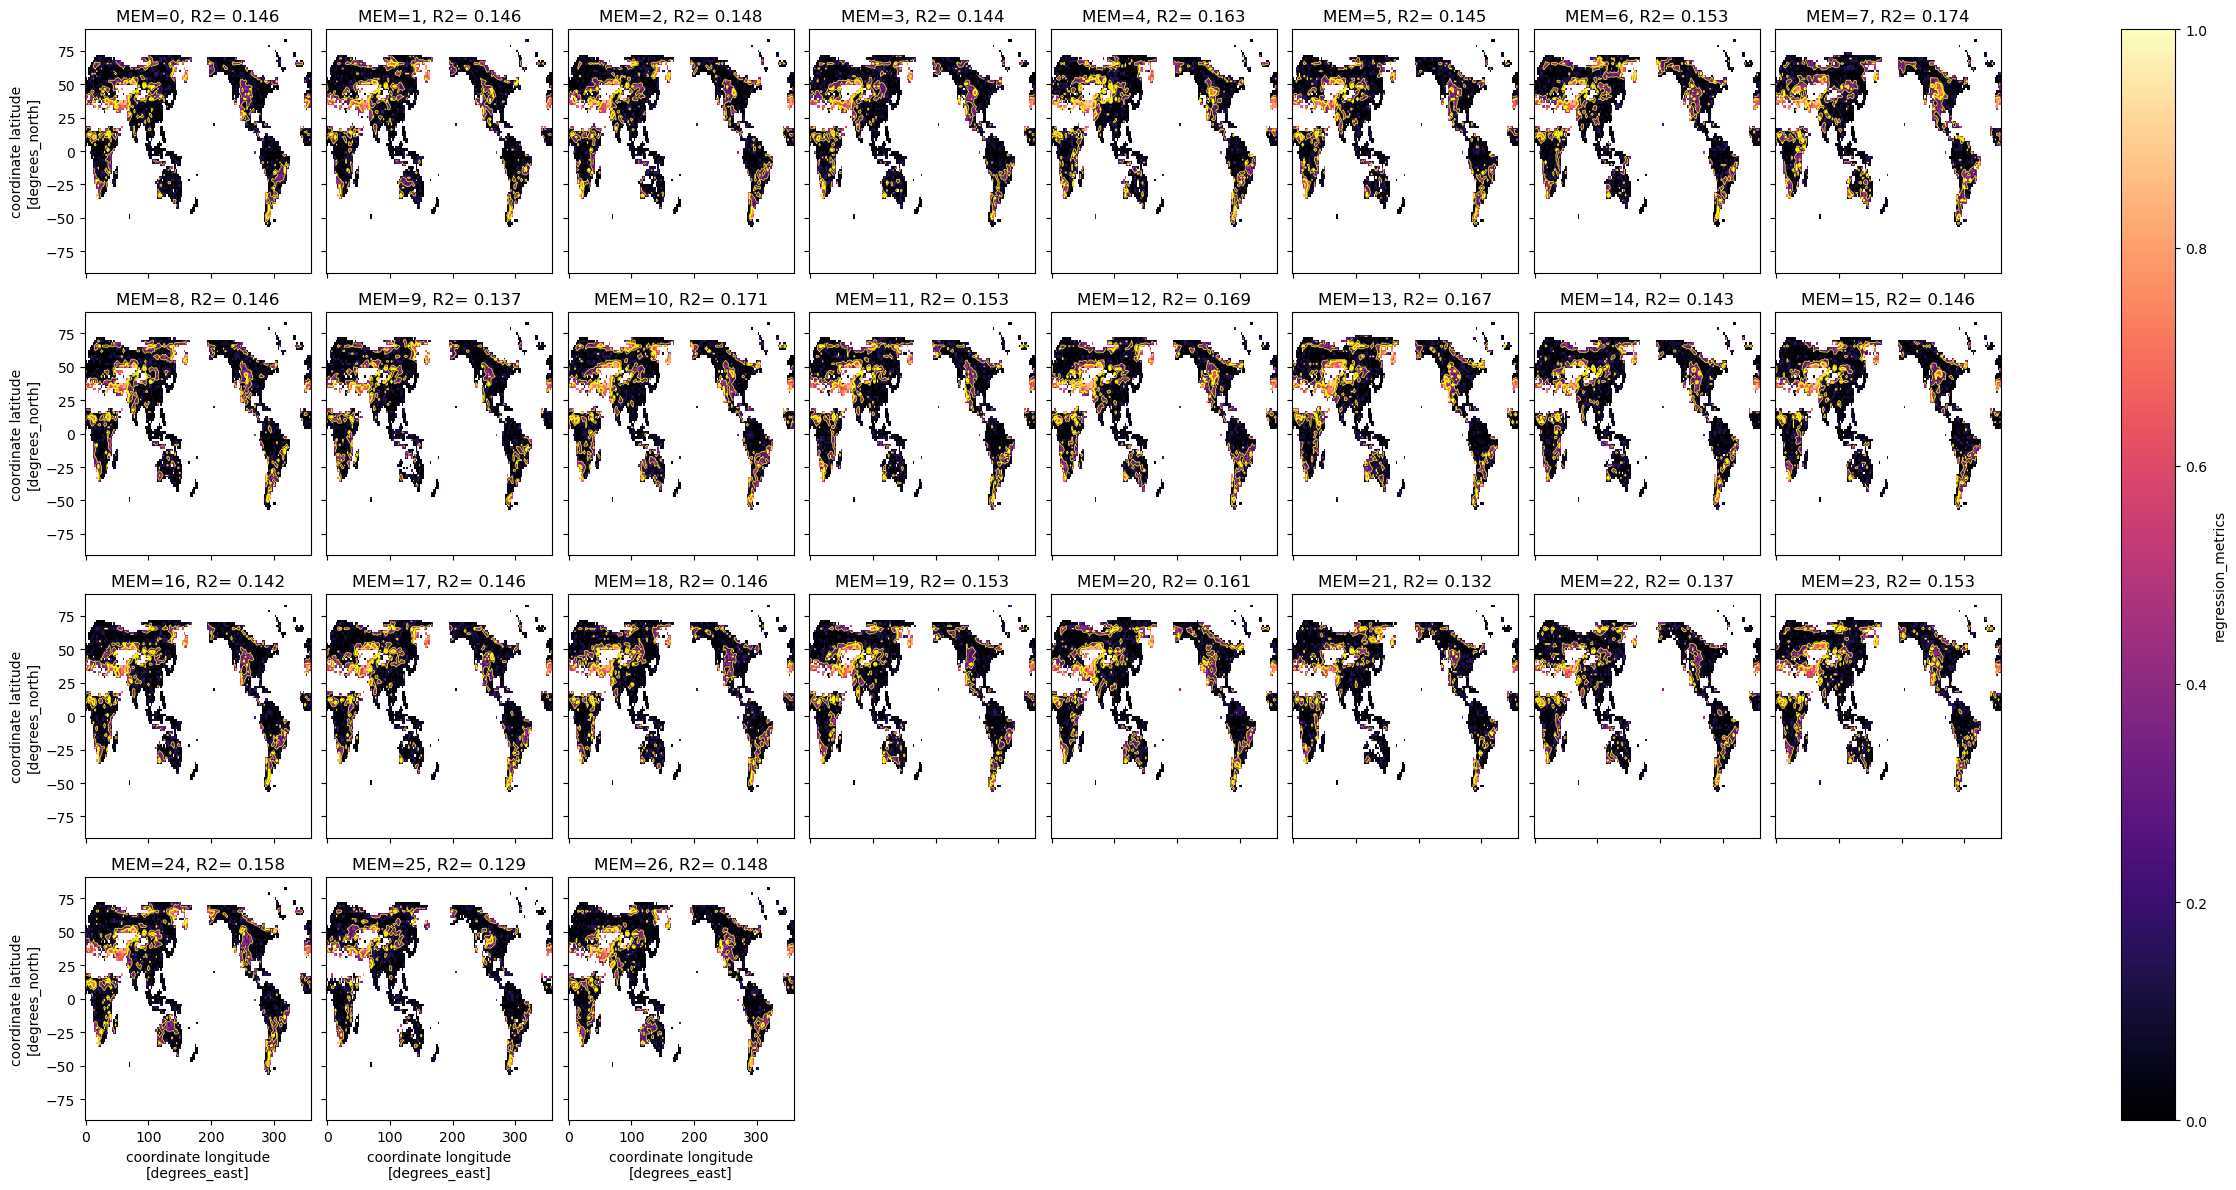

In [28]:
fg = mlr_time_lai.regression_metrics.sel(metric="R2").plot(col='member', col_wrap=8, vmin=0, vmax=1, cmap='magma')

for i in range(27):
    ax = fg.axs.ravel()[i]

    mlr_time_lai.regression_metrics.isel(member=i).sel(metric='R2').plot.contour(
        ax=fg.axs.ravel()[i],
        levels=[0.5],
        colors='yellow',
        linewidths=1,
        add_labels=False,
    )

    mlr_time_lai.regression_metrics.isel(member=i).sel(metric='R2').plot.contour(
        ax=fg.axs.ravel()[i],
        levels=[0.2],
        colors='yellow',
        linewidths=0.5,
        add_labels=False,
    )

    r2 = mlr_time_lai.regression_metrics.isel(member=i).sel(metric='R2').mean(dim=['lat', 'lon']).values
    ax.set_title(f"MEM={i}, R2={r2: 0.3f}")

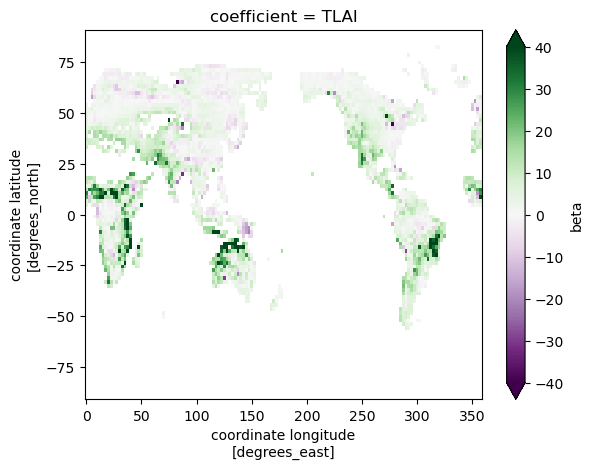

In [12]:
mlr_time_lai.beta.sel(coefficient="TLAI").mean(dim='member').plot(vmin=-40, vmax=40, cmap='PRGn')

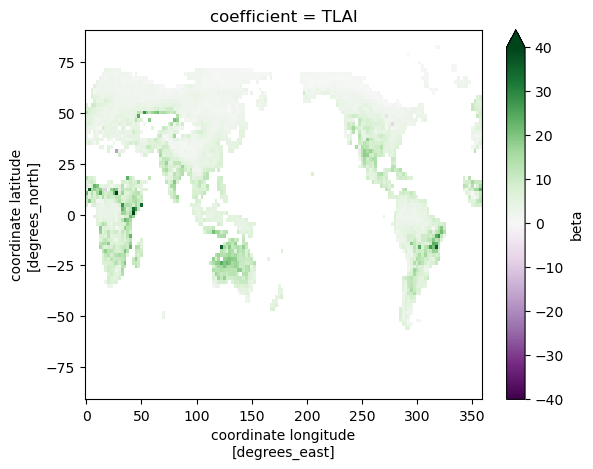

In [10]:
mlr_ens_lai.beta.sel(coefficient="TLAI").plot(vmin=-40, vmax=40, cmap='PRGn')

Text(0.5, 1.0, 'MLR$_{ann}$ ; R$^2$')

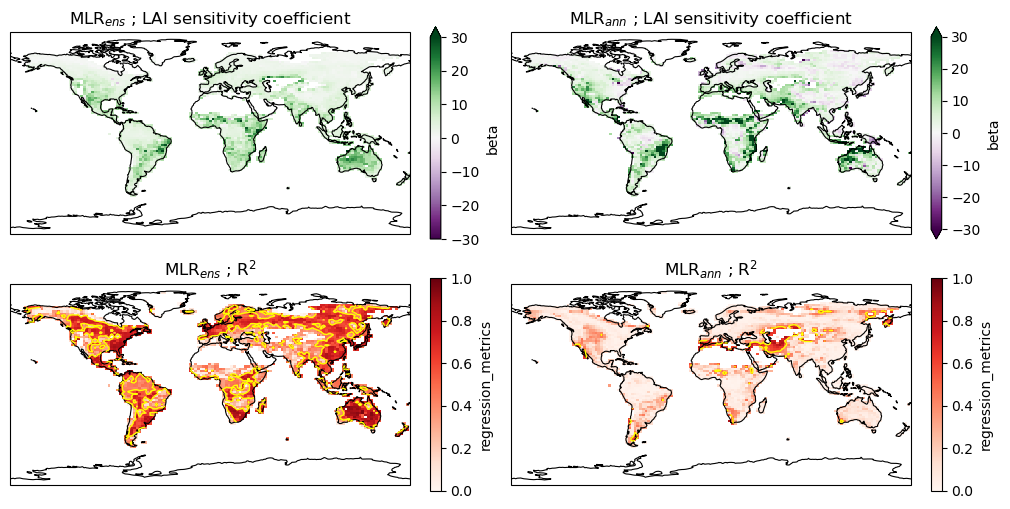

In [41]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5), layout='constrained', subplot_kw={'projection': ccrs.PlateCarree()})
axs = axes.ravel()

vmin_sens = -30
vmax_sens = 30

vmin_r2 = 0
vmax_r2 = 1

mlr_ens_lai.beta.sel(coefficient="TLAI").plot(ax=axs[0], vmin=vmin_sens, vmax=vmax_sens, cmap='PRGn', transform=ccrs.PlateCarree())
mlr_time_lai.beta.sel(coefficient="TLAI").mean(dim='member').plot(ax=axs[1], vmin=vmin_sens, vmax=vmax_sens, cmap='PRGn', transform=ccrs.PlateCarree())

fg_ens = mlr_ens_lai.regression_metrics.sel(metric="R2").plot(ax=axs[2], vmin=vmin_r2, vmax=vmax_r2, cmap='Reds')
# fg_ens.cbar.ax.axhline(0.5, c='yellow', lw=2)
mlr_ens_lai.regression_metrics.sel(metric='R2').plot.contour(
    ax=axs[2],
    levels=[0.5],
    colors='yellow',
    linewidths=1,
    add_labels=False,
    transform=ccrs.PlateCarree()
)
# mlr_ens_lai.regression_metrics.sel(metric='R2').plot.contour(
#     ax=axs[2],
#     levels=[0.2],
#     colors='yellow',
#     linewidths=0.5,
#     add_labels=False,
#     transform=ccrs.PlateCarree()
# )

fg_time = mlr_time_lai.regression_metrics.mean(dim='member').sel(metric="R2").plot(ax=axs[3], vmin=vmin_r2, vmax=vmax_r2, cmap='Reds')
# fg_time.cbar.ax.axhline(0.5, c='yellow', lw=2)
mlr_time_lai.regression_metrics.mean(dim='member').sel(metric='R2').plot.contour(
    ax=axs[3],
    levels=[0.5],
    colors='yellow',
    linewidths=1,
    add_labels=False,
    transform=ccrs.PlateCarree()
)
# mlr_time_lai.regression_metrics.mean(dim='member').sel(metric='R2').plot.contour(
#     ax=axs[3],
#     levels=[0.2],
#     colors='yellow',
#     linewidths=0.5,
#     add_labels=False,
#     transform=ccrs.PlateCarree()
# )

for ax in axs:
    ax.coastlines(lw=0.8, color='k')

axs[0].set_title("MLR$_{ens}$ ; LAI sensitivity coefficient")
axs[1].set_title("MLR$_{ann}$ ; LAI sensitivity coefficient")
axs[2].set_title("MLR$_{ens}$ ; R$^2$")
axs[3].set_title("MLR$_{ann}$ ; R$^2$")

# Exploration

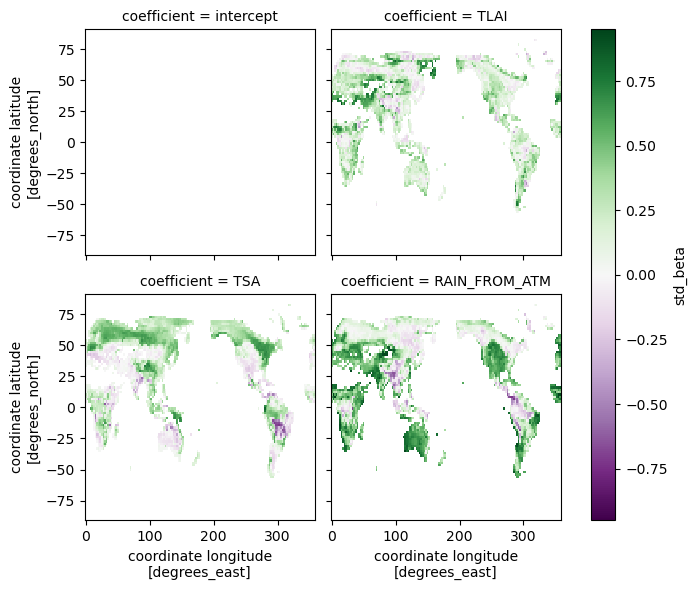

In [38]:
mlr_time_nors.std_beta.mean(dim='member').plot(col='coefficient', col_wrap=2, cmap='PRGn')

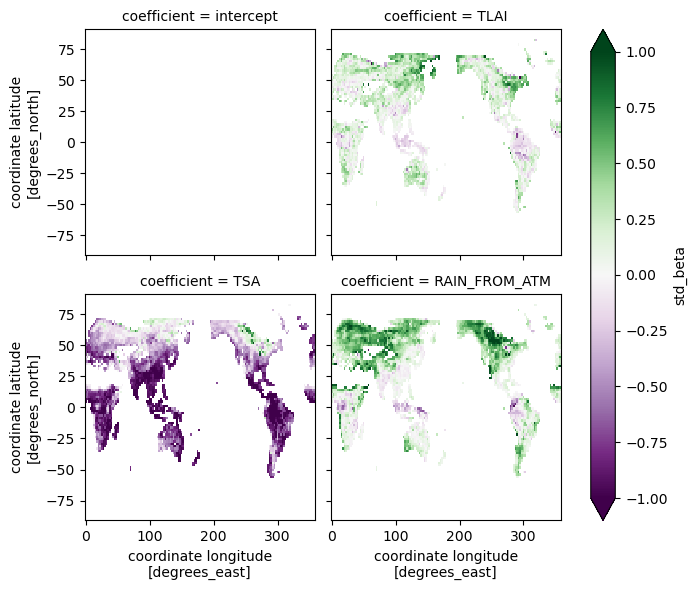

In [39]:
mlr_ens_nors.std_beta.plot(col='coefficient', col_wrap=2, cmap='PRGn', vmin=-1, vmax=1)

In [7]:
mlr_time_vif5mask = vif_time.vif.max(dim='predictor') < 5
mlr_time_nors_vif5mask = vif_time_nors.vif.max(dim='predictor') < 5

mlr_ens_vif5mask = vif_ens.vif.max(dim='predictor') < 5
mlr_ens_nors_vif5mask = vif_ens_nors.vif.max(dim='predictor') < 5

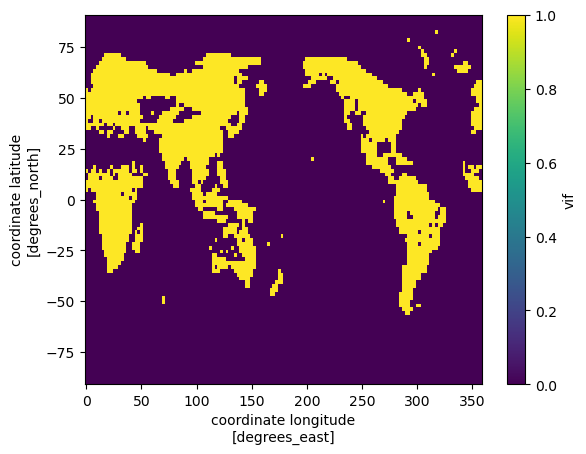

In [8]:
mlr_time_nors_vif5mask.min(dim='member').plot()

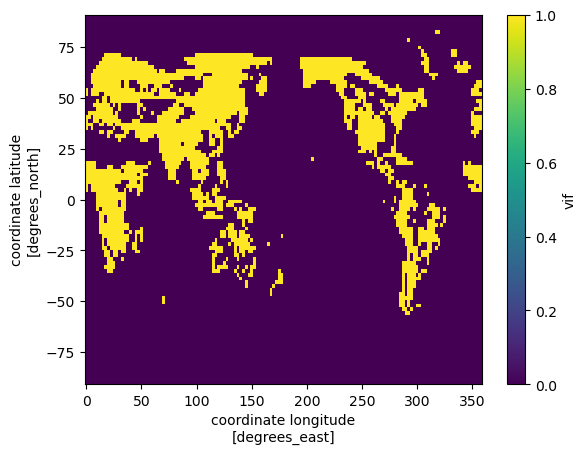

In [9]:
mlr_ens_nors_vif5mask.plot()

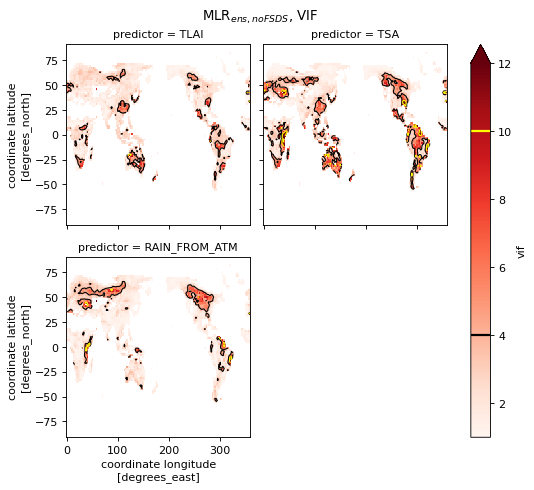

In [30]:
fg = vif_ens_nors.vif.plot(col='predictor', col_wrap=2, vmin=1, vmax=12, robust=True, cmap='Reds')
for i in range(3):
    vif_ens_nors.vif.isel(predictor=i).plot.contour(
        ax=fg.axs.ravel()[i],
        levels=[4],
        colors='k',
        linewidths=1,
        add_labels=False,
    )

    vif_ens_nors.vif.isel(predictor=i).plot.contour(
        ax=fg.axs.ravel()[i],
        levels=[10],
        colors='yellow',
        linewidths=1,
        add_labels=False,
    )

fg.cbar.ax.axhline(4, c='k', lw=2)
fg.cbar.ax.axhline(10, c='yellow', lw=2)

fg.fig.suptitle(f'MLR$_{{ens,noFSDS}}$, VIF', x=0.475, y=1.02)
fg.fig.set_dpi(DPI)

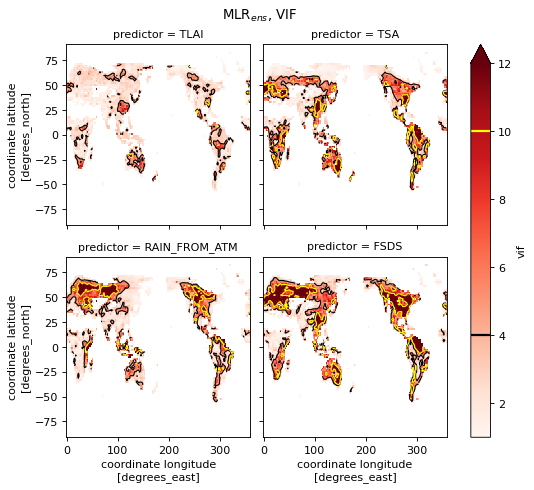

In [31]:
fg = vif_ens.vif.plot(col='predictor', col_wrap=2, vmin=1, vmax=12, robust=True, cmap='Reds')
for i in range(4):
    vif_ens.vif.isel(predictor=i).plot.contour(
        ax=fg.axs.ravel()[i],
        levels=[4],
        colors='k',
        linewidths=1,
        add_labels=False,
    )

    vif_ens.vif.isel(predictor=i).plot.contour(
        ax=fg.axs.ravel()[i],
        levels=[10],
        colors='yellow',
        linewidths=1,
        add_labels=False,
    )

fg.cbar.ax.axhline(4, c='k', lw=2)
fg.cbar.ax.axhline(10, c='yellow', lw=2)

fg.fig.suptitle(f'MLR$_{{ens}}$, VIF', x=0.475, y=1.02)
fg.fig.set_dpi(DPI)

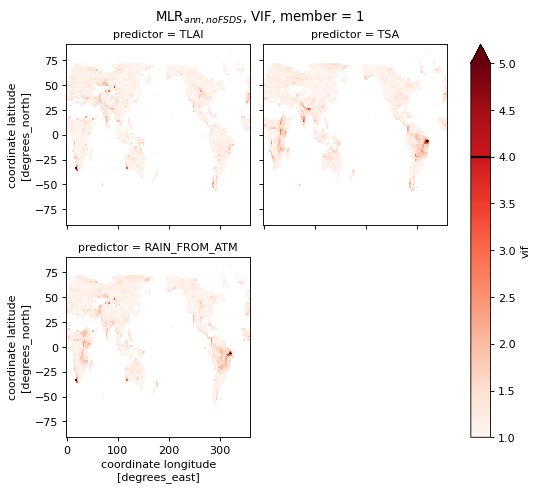

In [32]:
m = 1
fg = vif_time_nors.vif.sel(member=m).plot(col='predictor', col_wrap=2, vmin=1, vmax=5, robust=True, cmap='Reds')
for i in range(3):
    vif_time_nors.vif.isel(predictor=i).sel(member=m).plot.contour(
        ax=fg.axs.ravel()[i],
        levels=[4],
        colors='k',
        linewidths=1,
        add_labels=False,
    )

    vif_time_nors.vif.isel(predictor=i).sel(member=m).plot.contour(
        ax=fg.axs.ravel()[i],
        levels=[10],
        colors='yellow',
        linewidths=1,
        add_labels=False,
    )

fg.cbar.ax.axhline(4, c='k', lw=2)
fg.cbar.ax.axhline(10, c='yellow', lw=2)

fg.fig.suptitle(f'MLR$_{{ann,noFSDS}}$, VIF, member = {m}', x=0.475, y=1.02)
fg.fig.set_dpi(DPI)

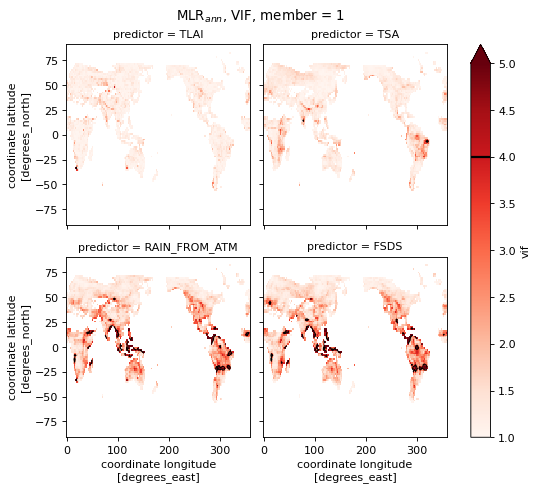

In [33]:
m = 1
fg = vif_time.vif.sel(member=m).plot(col='predictor', col_wrap=2, vmin=1, vmax=5, robust=True, cmap='Reds')
for i in range(4):
    vif_time.vif.isel(predictor=i).sel(member=m).plot.contour(
        ax=fg.axs.ravel()[i],
        levels=[4],
        colors='k',
        linewidths=1,
        add_labels=False,
    )

fg.cbar.ax.axhline(4, c='k', lw=2)

fg.fig.suptitle(f'MLR$_{{ann}}$, VIF, member = {m}', x=0.475, y=1.02)
fg.fig.set_dpi(DPI)

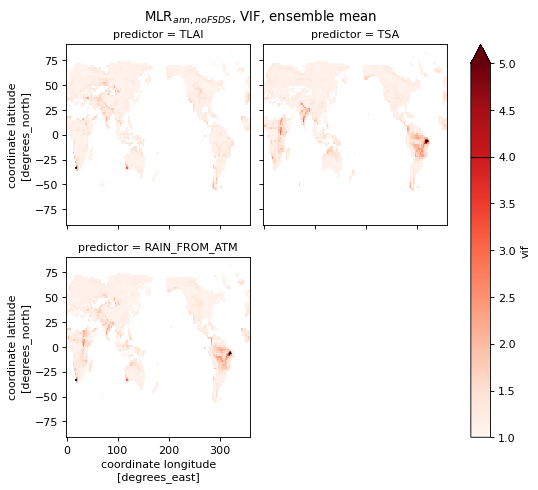

In [34]:
fg = vif_time_nors.vif.mean(dim='member').plot(col='predictor', col_wrap=2, vmin=1, vmax=5, robust=True, cmap='Reds')
for i in range(3):
    vif_time_nors.vif.mean(dim='member').isel(predictor=i).plot.contour(
        ax=fg.axs.ravel()[i],
        levels=[4],
        colors='black',
        linewidths=1,
        add_labels=False,
    )

fg.cbar.ax.axhline(4, c='k', lw=1)

fg.fig.suptitle(f'MLR$_{{ann,noFSDS}}$, VIF, ensemble mean', x=0.475, y=1.02)
fg.fig.set_dpi(DPI)

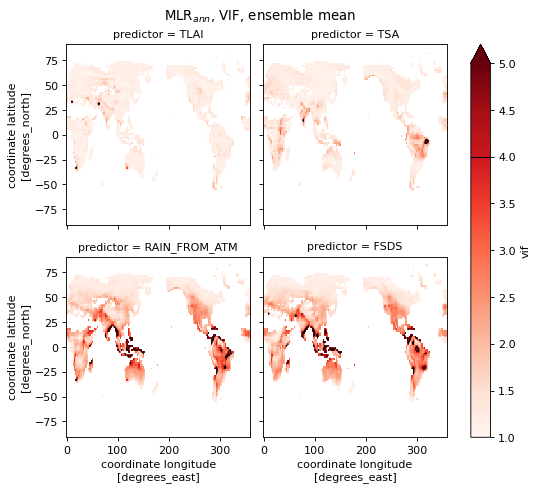

In [35]:
fg = vif_time.vif.mean(dim='member').plot(col='predictor', col_wrap=2, vmin=1, vmax=5, robust=True, cmap='Reds')
for i in range(4):
    vif_time.vif.mean(dim='member').isel(predictor=i).plot.contour(
        ax=fg.axs.ravel()[i],
        levels=[4],
        colors='black',
        linewidths=1,
        add_labels=False,
    )

fg.cbar.ax.axhline(4, c='k', lw=1)

fg.fig.suptitle(f'MLR$_{{ann}}$, VIF, ensemble mean', x=0.475, y=1.02)
fg.fig.set_dpi(DPI)

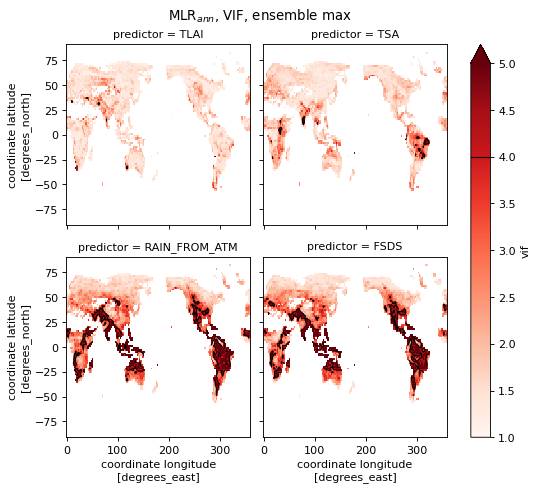

In [36]:
m = 1
fg = vif_time.vif.max(dim='member').plot(col='predictor', col_wrap=2, vmin=1, vmax=5, robust=True, cmap='Reds')
for i in range(4):
    vif_time.vif.max(dim='member').isel(predictor=i).plot.contour(
        ax=fg.axs.ravel()[i],
        levels=[4],
        colors='black',
        linewidths=1,
        add_labels=False,
    )

fg.cbar.ax.axhline(4, c='k', lw=1)

fg.fig.suptitle(f'MLR$_{{ann}}$, VIF, ensemble max', x=0.475, y=1.02)
fg.fig.set_dpi(DPI)

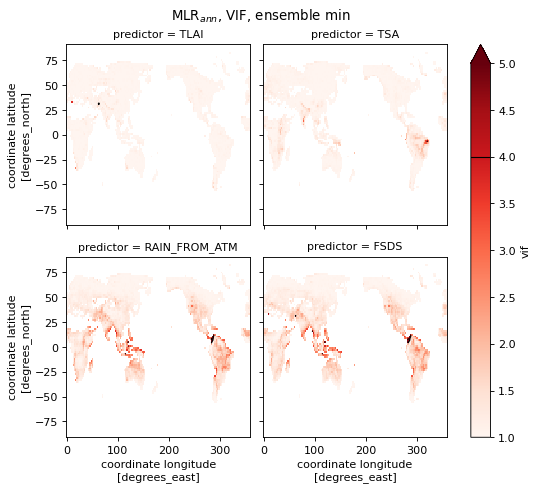

In [37]:
fg = vif_time.vif.min(dim='member').plot(col='predictor', col_wrap=2, vmin=1, vmax=5, robust=True, cmap='Reds')
for i in range(4):
    vif_time.vif.min(dim='member').isel(predictor=i).plot.contour(
        ax=fg.axs.ravel()[i],
        levels=[4],
        colors='black',
        linewidths=1,
        add_labels=False,
    )
fg.cbar.ax.axhline(4, c='k', lw=1)

fg.fig.suptitle(f'MLR$_{{ann}}$, VIF, ensemble min', x=0.475, y=1.02)
fg.fig.set_dpi(DPI)

# MLR - time

## Coefficients

Text(0.5, 0.98, 'MLR across time, sensitivity coefficients in their own units')

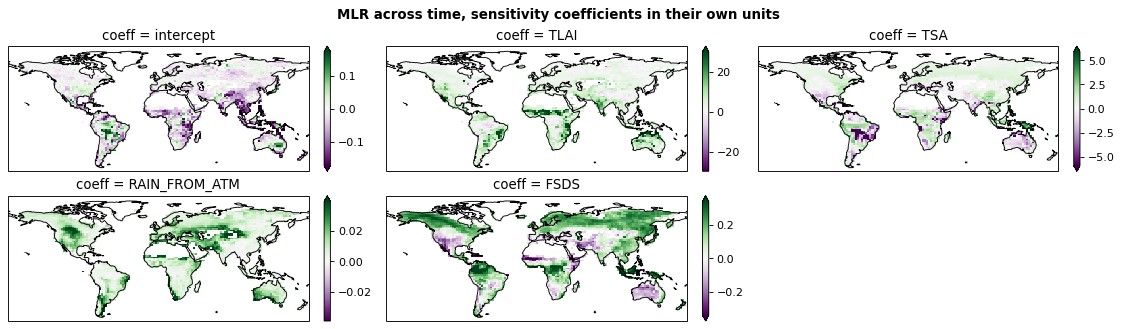

In [18]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 4),
    sharex=True, sharey=True,
    layout='constrained',
    subplot_kw={'projection': ccrs.PlateCarree()},
    dpi=DPI
)
axs = axes.ravel()

for i in range(5):
    mlr_time.beta.mean(dim='member').isel(coefficient=i).plot(
        ax=axs[i],
        robust=True,
        add_labels=False,
        transform=ccrs.PlateCarree(),
        cbar_kwargs={'fraction': 0.025},
        cmap='PRGn'
    )
    axs[i].set_extent([-180, 180, -60, 90])
    axs[i].coastlines(lw=0.8, color='k')
    axs[i].set_title(f"coeff = {COEFFS[i]}")

axs[-1].remove()
fig.suptitle("MLR across time, sensitivity coefficients in their own units", fontweight='bold')

## Fit metrics

### R2

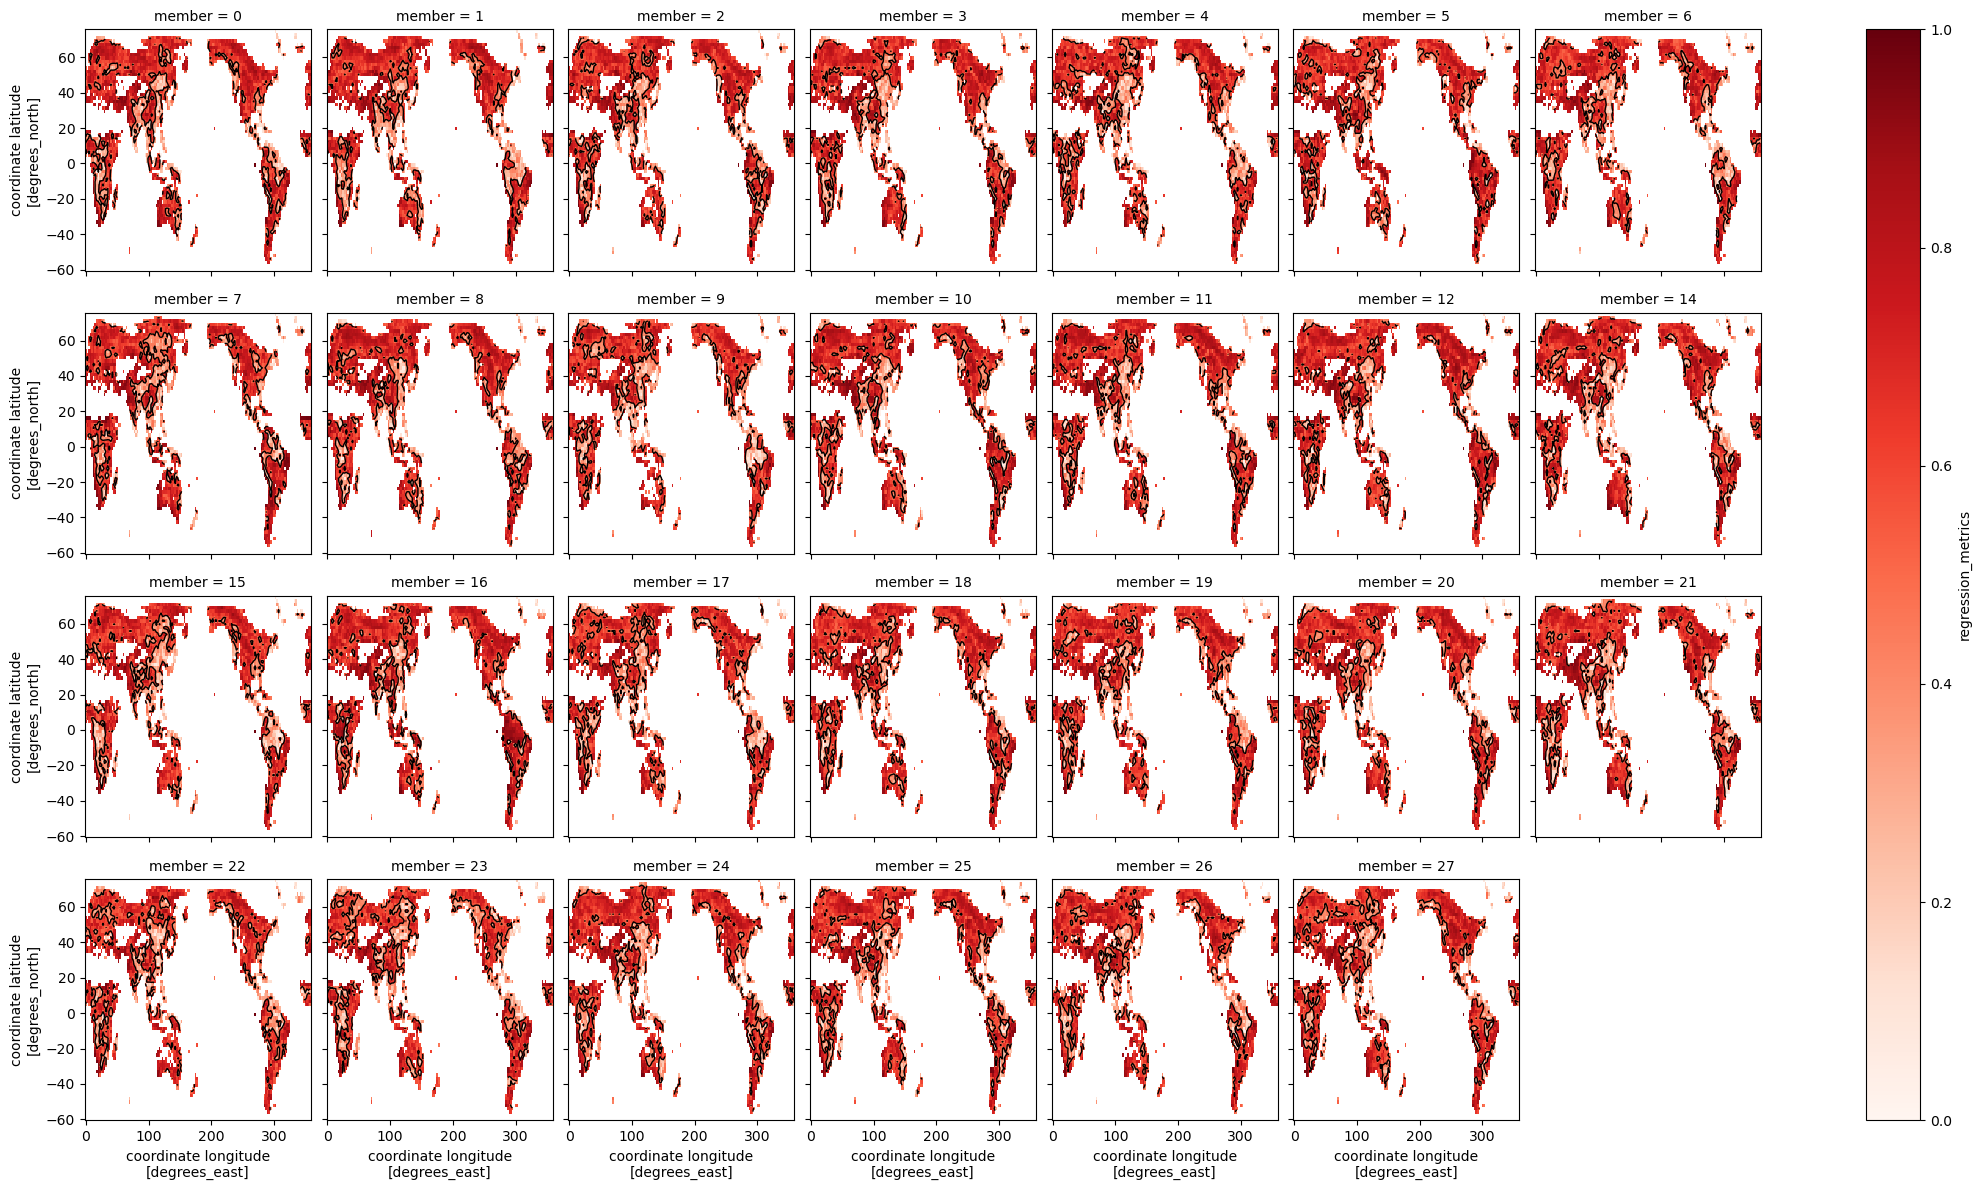

In [19]:
x = mlr_time.regression_metrics.sel(metric='R2', lat=slice(-60, 75))
fg = x.plot(col='member', col_wrap=7, vmin=0, vmax=1, cmap='Reds')
axs = fg.axs.ravel()

for i in range(27):
    x.isel(member=i).plot.contour(
        ax=axs[i],
        levels=[0.5],
        colors='k',
        linewidths=1,
        add_labels=False,
    )

### RMSE

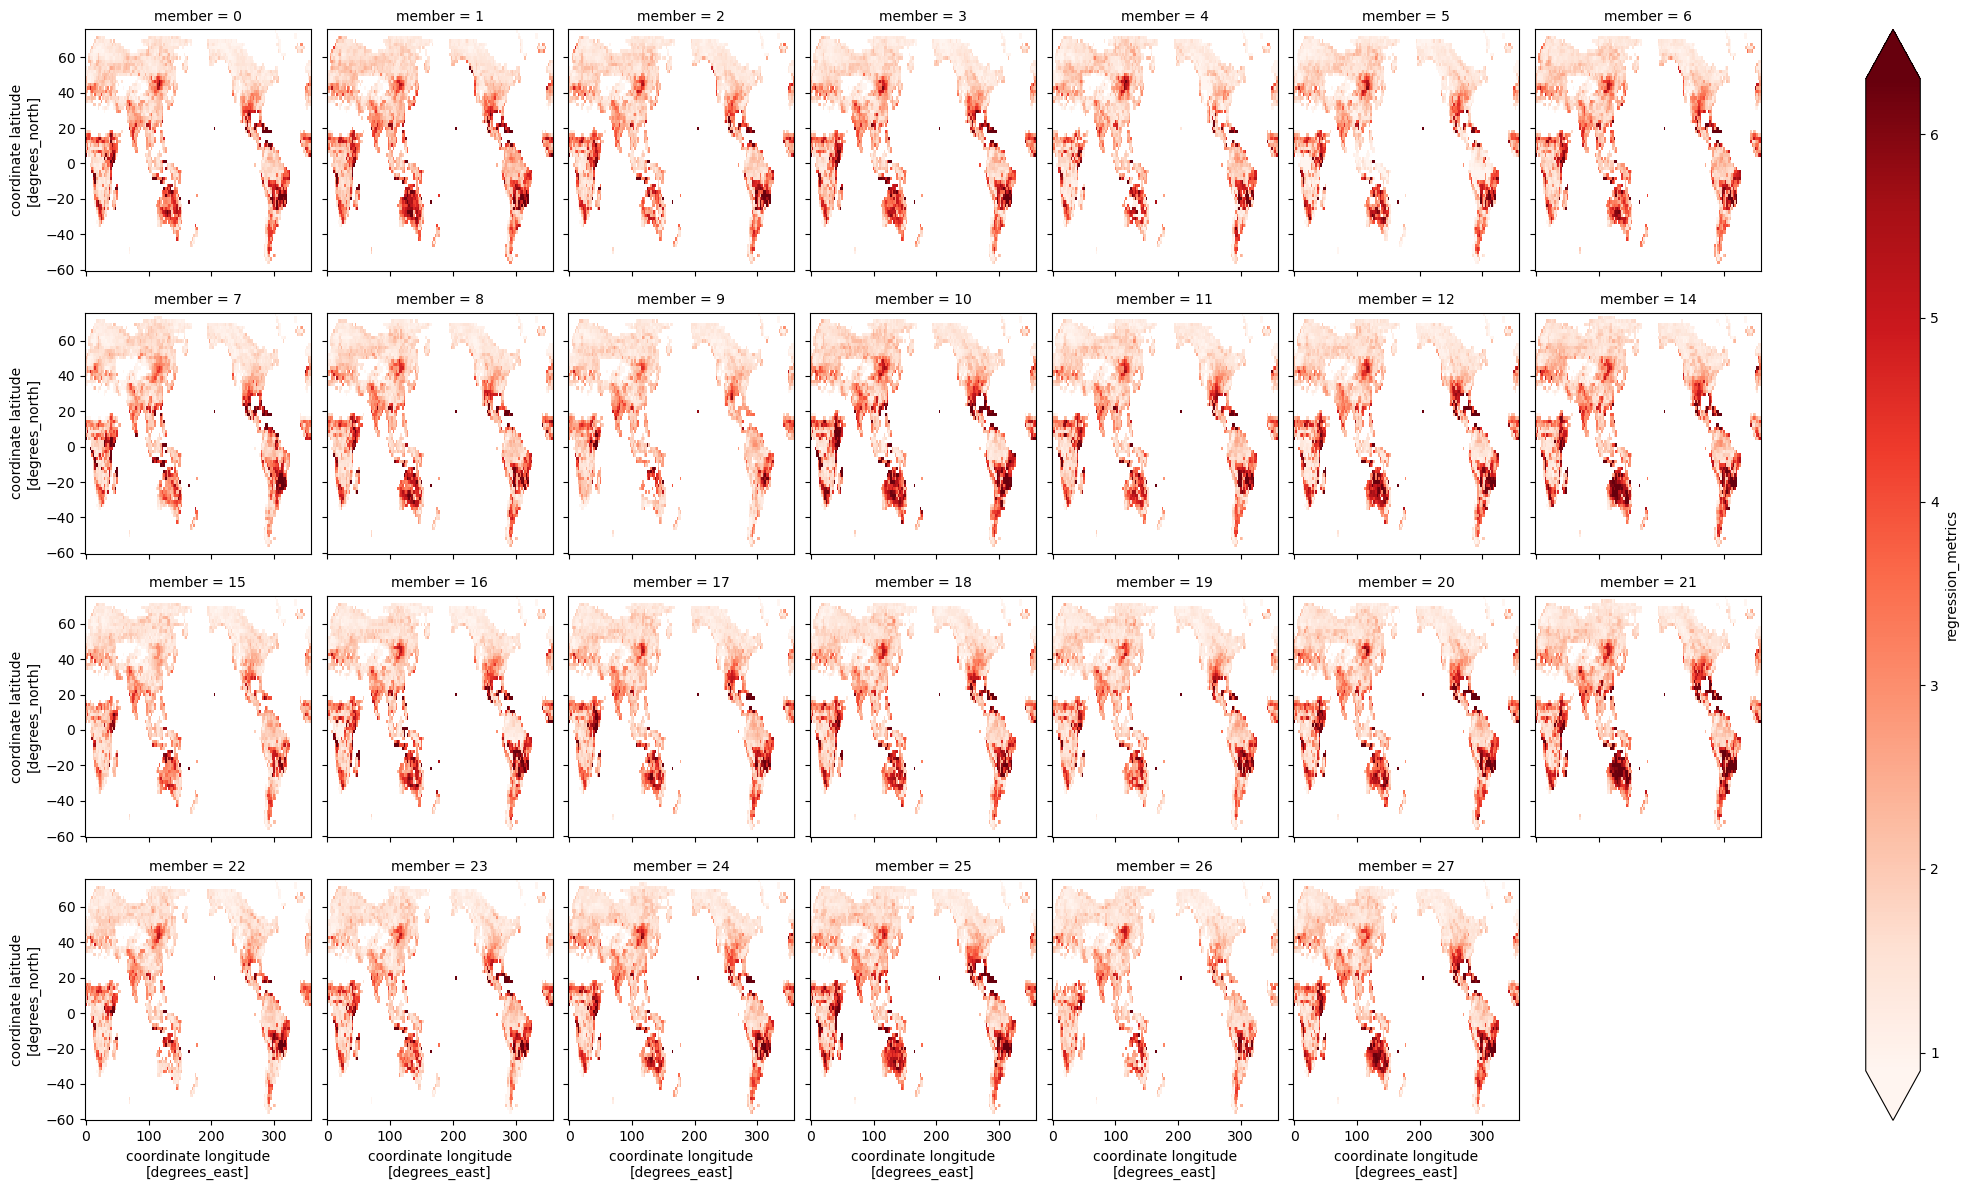

In [20]:
x = mlr_time.regression_metrics.sel(metric='RMSE', lat=slice(-60, 75))
fg = x.plot(col='member', col_wrap=7, cmap='Reds', robust=True)
axs = fg.axs.ravel()

# for i in range(27):
#     x.isel(member=i).plot.contour(
#         ax=axs[i],
#         levels=[0.5],
#         colors='k',
#         linewidths=1,
#         add_labels=False,
#     )

# MLR - ensemble

## Coefficients

Text(0.5, 0.98, 'MLR across ensemble, sensitivity coefficients in their own units')

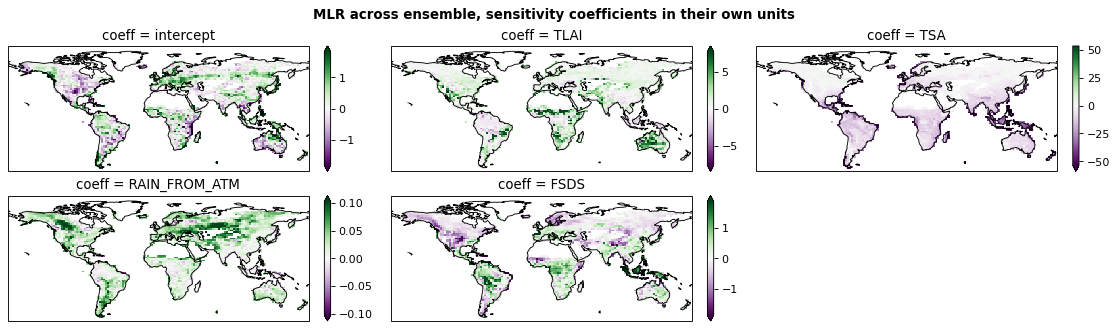

In [21]:
fig, axes = plt.subplots(
    2, 3,
    figsize=(14, 4),
    sharex=True, sharey=True,
    layout='constrained',
    subplot_kw={'projection': ccrs.PlateCarree()},
    dpi=DPI
)
axs = axes.ravel()

for i in range(5):
    mlr_ens.beta.isel(coefficient=i).plot(
        ax=axs[i],
        robust=True,
        add_labels=False,
        transform=ccrs.PlateCarree(),
        cbar_kwargs={'fraction': 0.025},
        cmap='PRGn'
    )
    axs[i].set_extent([-180, 180, -60, 90])
    axs[i].coastlines(lw=0.8, color='k')
    axs[i].set_title(f"coeff = {COEFFS[i]}")

axs[-1].remove()
fig.suptitle("MLR across ensemble, sensitivity coefficients in their own units", fontweight='bold')

In [22]:
_mlr_time.coefficient

NameError: name '_mlr_time' is not defined

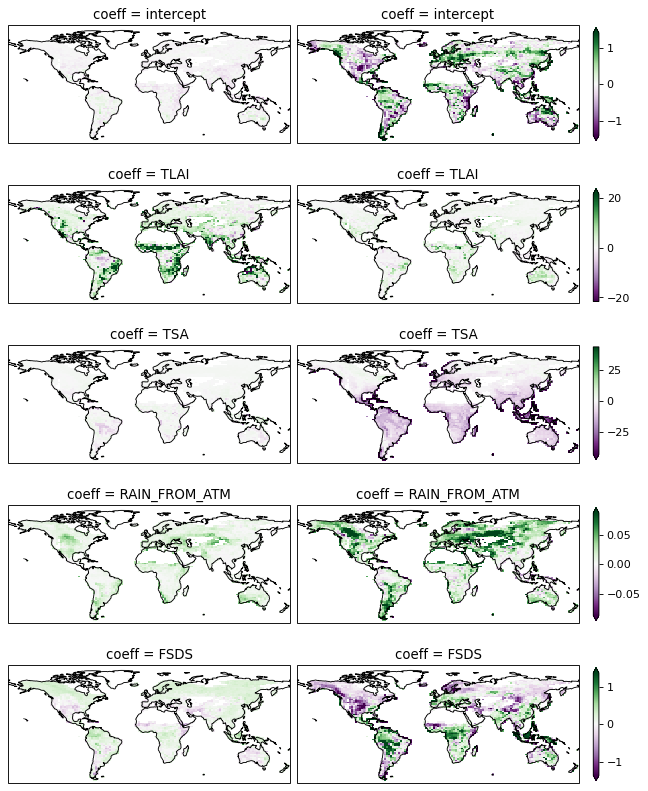

In [26]:
fig, axes = plt.subplots(
    5, 2,
    figsize=(8, 10),
    sharex=True, sharey=True,
    layout='constrained',
    subplot_kw={'projection': ccrs.PlateCarree()},
    dpi=DPI
)
axs = axes.ravel()

for i in range(5):
    # _mlr_time = mlr_time.beta.mean(dim='member').isel(coefficient=i)
    _mlr_time = mlr_time.beta.sel(member=0).isel(coefficient=i)

    _mlr_ens = mlr_ens.beta.isel(coefficient=i)

    p_low, p_high = 2, 98
    all_vals = np.concatenate([_mlr_time.values.ravel(), _mlr_ens.values.ravel()])
    vmin = np.nanpercentile(all_vals, p_low)
    vmax = np.nanpercentile(all_vals, p_high)
    vabs = max(abs(vmin), abs(vmax))

    _mlr_time.plot(
        ax=axs[2*i],
        vmin=-vabs,
        vmax=vabs,
        add_labels=False,
        transform=ccrs.PlateCarree(),
        # cbar_kwargs={'fraction': 0.025},
        cmap='PRGn',
        add_colorbar=False,
    )

    _mlr_ens.plot(
        ax=axs[2*i + 1],
        vmin=-vabs,
        vmax=vabs,
        add_labels=False,
        transform=ccrs.PlateCarree(),
        cbar_kwargs={'fraction': 0.02},
        cmap='PRGn'
    )

    for j in range(2):
        axes[i, j].set_extent([-180, 180, -60, 90])
        axes[i, j].coastlines(lw=0.8, color='k')
        axes[i, j].set_title(f"coeff = {COEFFS[i]}")

# plt.text(0.25, 1, "time", transform=fig.transFigure, ha='center', va='top', fontsize=12, fontweight='bold')
# plt.text(0.75, 0.98, "ensemble", transform=fig.transFigure, ha='center', va='top', fontsize=12, fontweight='bold')

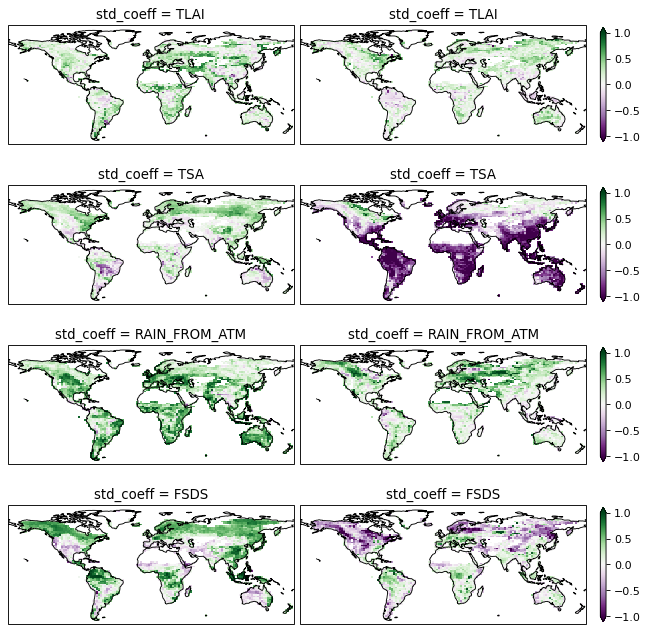

In [25]:
fig, axes = plt.subplots(
    4, 2,
    figsize=(8, 8),
    sharex=True, sharey=True,
    layout='constrained',
    subplot_kw={'projection': ccrs.PlateCarree()},
    dpi=DPI
)
axs = axes.ravel()

for i in range(4):
    # _mlr_time = mlr_time.std_beta.mean(dim='member').isel(coefficient=i+1)
    _mlr_time = mlr_time.std_beta.sel(member=0).isel(coefficient=i+1)

    _mlr_ens = mlr_ens.std_beta.isel(coefficient=i+1)

    # p_low, p_high = 2, 98
    # all_vals = np.concatenate([_mlr_time.values.ravel(), _mlr_ens.values.ravel()])
    # vmin = np.nanpercentile(all_vals, p_low)
    # vmax = np.nanpercentile(all_vals, p_high)
    # vabs = max(abs(vmin), abs(vmax))

    vabs = 1

    _mlr_time.plot(
        ax=axs[2*i],
        vmin=-vabs,
        vmax=vabs,
        add_labels=False,
        transform=ccrs.PlateCarree(),
        # cbar_kwargs={'fraction': 0.025},
        cmap='PRGn',
        add_colorbar=False,
    )

    _mlr_ens.plot(
        ax=axs[2*i + 1],
        vmin=-vabs,
        vmax=vabs,
        add_labels=False,
        transform=ccrs.PlateCarree(),
        cbar_kwargs={'fraction': 0.02},
        cmap='PRGn'
    )

    for j in range(2):
        axes[i, j].set_extent([-180, 180, -60, 90])
        axes[i, j].coastlines(lw=0.8, color='k')
        axes[i, j].set_title(f"std_coeff = {COEFFS[i+1]}")

Text(0.5, 1.0, 'MLR$_{{ens}}$')

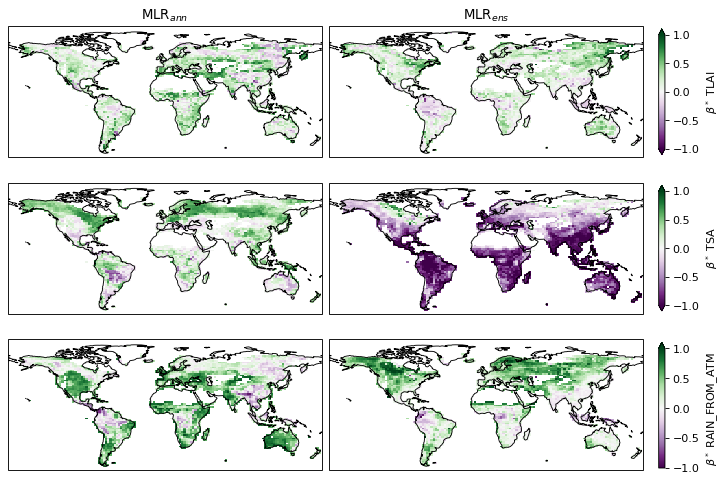

In [23]:
fig, axes = plt.subplots(
    3, 2,
    figsize=(9, 6),
    sharex=True, sharey=True,
    layout='constrained',
    subplot_kw={'projection': ccrs.PlateCarree()},
    dpi=DPI
)
axs = axes.ravel()

for i in range(3):
    # _mlr_time = mlr_time.std_beta.mean(dim='member').isel(coefficient=i+1)
    _mlr_time = mlr_time_nors.std_beta.sel(member=0).isel(coefficient=i+1)

    _mlr_ens = mlr_ens_nors.std_beta.isel(coefficient=i+1)

    # p_low, p_high = 2, 98
    # all_vals = np.concatenate([_mlr_time.values.ravel(), _mlr_ens.values.ravel()])
    # vmin = np.nanpercentile(all_vals, p_low)
    # vmax = np.nanpercentile(all_vals, p_high)
    # vabs = max(abs(vmin), abs(vmax))

    vabs = 1

    _mlr_time.plot(
        ax=axs[2*i],
        vmin=-vabs,
        vmax=vabs,
        add_labels=False,
        transform=ccrs.PlateCarree(),
        # cbar_kwargs={'fraction': 0.025},
        cmap='PRGn',
        add_colorbar=False,
    )

    _mlr_ens.plot(
        ax=axs[2*i + 1],
        vmin=-vabs,
        vmax=vabs,
        add_labels=False,
        transform=ccrs.PlateCarree(),
        cbar_kwargs={'fraction': 0.02, 'label': f'$\\beta^*$ {COEFFS[i+1]}'},
        cmap='PRGn'
    )

    for j in range(2):
        axes[i, j].set_extent([-180, 180, -60, 90])
        axes[i, j].coastlines(lw=0.8, color='k')
        # axes[i, j].set_title(f"std_coeff = {COEFFS[i+1]}")

axes[0, 0].set_title('MLR$_{{ann}}$')
axes[0, 1].set_title('MLR$_{{ens}}$')

Text(0.5, 0.98, 'standardized regression coefficients where $VIF_p < 5, \\; p \\in \\{\\text{TLAI}, \\text{TSA}, \\text{RAIN}\\}$')

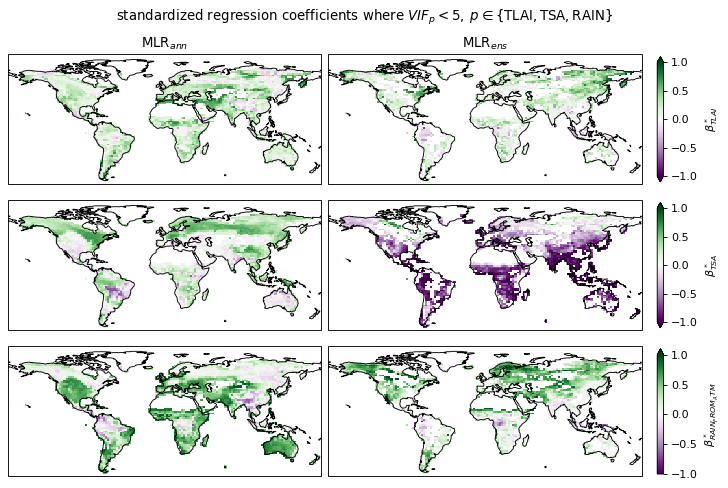

In [24]:
fig, axes = plt.subplots(
    3, 2,
    figsize=(9, 6),
    sharex=True, sharey=True,
    layout='constrained',
    subplot_kw={'projection': ccrs.PlateCarree()},
    dpi=DPI
)
axs = axes.ravel()

for i in range(3):
    # _mlr_time = mlr_time.std_beta.mean(dim='member').isel(coefficient=i+1)
    _mlr_time = mlr_time_nors.std_beta.where(mlr_time_nors_vif5mask).mean(dim='member').isel(coefficient=i+1)

    _mlr_ens = mlr_ens_nors.std_beta.where(mlr_ens_nors_vif5mask).isel(coefficient=i+1)

    # p_low, p_high = 2, 98
    # all_vals = np.concatenate([_mlr_time.values.ravel(), _mlr_ens.values.ravel()])
    # vmin = np.nanpercentile(all_vals, p_low)
    # vmax = np.nanpercentile(all_vals, p_high)
    # vabs = max(abs(vmin), abs(vmax))

    vabs = 1

    _mlr_time.plot(
        ax=axs[2*i],
        vmin=-vabs,
        vmax=vabs,
        add_labels=False,
        transform=ccrs.PlateCarree(),
        # cbar_kwargs={'fraction': 0.025},
        cmap='PRGn',
        add_colorbar=False,
    )

    _mlr_ens.plot(
        ax=axs[2*i + 1],
        vmin=-vabs,
        vmax=vabs,
        add_labels=False,
        transform=ccrs.PlateCarree(),
        cbar_kwargs={'fraction': 0.02, 'label': f'$\\beta^*_{{{COEFFS[i+1]}}}$'},
        cmap='PRGn'
    )

    for j in range(2):
        axes[i, j].set_extent([-180, 180, -60, 90])
        axes[i, j].coastlines(lw=0.8, color='k')
        # axes[i, j].set_title(f"std_coeff = {COEFFS[i+1]}")

axes[0, 0].set_title('MLR$_{{ann}}$')
axes[0, 1].set_title('MLR$_{{ens}}$')

fig.suptitle("standardized regression coefficients where $VIF_p < 5, \\; p \\in \\{\\text{TLAI}, \\text{TSA}, \\text{RAIN}\\}$")

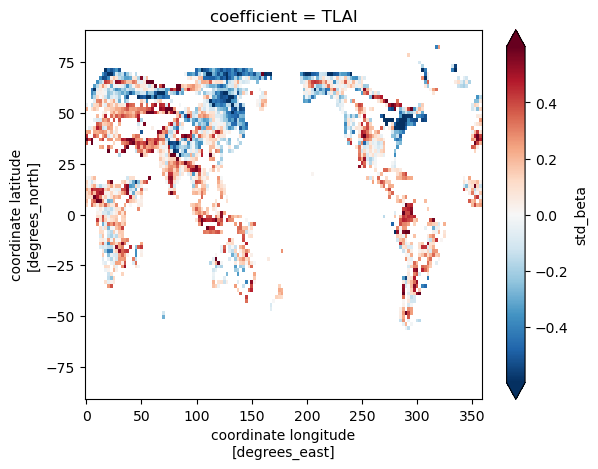

In [ ]:
x = (
    mlr_time_nors.std_beta.where(mlr_time_nors_vif5mask).mean(dim='member').isel(coefficient=1) -
    mlr_ens_nors.std_beta.where(mlr_ens_nors_vif5mask).isel(coefficient=1)
)
x.plot(robust=True)